# От Score товара к выбору итоговой ассортиментной матрицы

Продолжение [`../Кластеризация точек продаж`](../Кластеризация%20точек%20продаж): там точки сети разбиты на
сегменты, здесь для каждого сегмента строится и выбирается конкретная товарная матрица.

Три шага:

1. посчитать **Score** каждого товара внутри его **юнита** - группы взаимозаменяемых товаров;
2. разделить юниты на классы **A/B/C** по вкладу в Score сегмента;
3. сгенерировать несколько **кандидатов на матрицу** двумя методами и выбрать лучший, сравнив каждого с
   действующей матрицей по деньгам: остатки, выручка, прибыль.

**Про данные.** Расчёт идёт на синтетических данных из общей базы [`../synthetic_data`](../synthetic_data):
справочник лекарств - из открытого реестра ЖНВЛП, продажи, остатки и действующая матрица сгенерированы,
сегменты точек - результат ноутбука кластеризации. Цифры не отражают реальный бизнес.

## Импорт библиотек и параметры

In [1]:
import os
import warnings

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import expon

pd.options.display.max_columns = 100
pd.options.display.float_format = '{:,.2f}'.format
sns.set_theme(style='whitegrid', font_scale=0.95)
plt.rcParams['figure.dpi'] = 110
warnings.filterwarnings('ignore', category=FutureWarning)

In [2]:
DB_PATH = os.environ.get('SYNTH_DB', '../synthetic_data/synthetic_projects.duckdb')

# Те же бизнес-фильтры чеков, что в кластеризации
EXCLUDED_SALE_TYPES = ('Опт', 'Маркетплейс')
MIN_SHELF_LIFE_MONTHS = 6

# Поправка Score на ценовой уровень товара: сегменту «эконом» важнее дешёвый товар, «премиум» - дорогой
PRICE_ADJUSTMENT = {
    'эконом':  {'low': 1.2, 'medium': 1.0, 'high': 0.8},
    'медиум':  {'low': 1.0, 'medium': 1.1, 'high': 1.0},
    'премиум': {'low': 0.8, 'medium': 1.0, 'high': 1.2},
}

# Границы накопительной доли для ABC-классификации юнитов внутри сегмента
ABC_LOWER_BOUND = 0.5   # до этой накопительной доли Score - класс A
ABC_UPPER_BOUND = 0.9   # до этой - класс B, дальше - класс C

# Кандидаты ABC-порогов: для класса юнита (A/B/C) - минимальная доля товара в Score своего юнита,
# плюс минимальный Score юнита для класса C (в рублях на точку за период)
ABC_THRESHOLD_CANDIDATES = pd.DataFrame([
    {"method": "мягкий",  "a": 0.05, "b": 0.10, "c": 0.20, "s_u": 0.0},
    {"method": "средний", "a": 0.10, "b": 0.15, "c": 0.25, "s_u": 50.0},
    {"method": "строгий", "a": 0.15, "b": 0.25, "c": 0.35, "s_u": 150.0},
])

# Несколько значений λ для экспоненциального метода отбора (чем больше λ, тем строже отбор)
LAMBDAS = [0.1, 0.25, 0.5]

# Защищённые позиции входят в матрицу независимо от Score: минимальный ассортимент и собственная марка
PROTECT_MIN_ASSORTMENT = True
PROTECT_OWN_BRAND = True

# Доля выручки исключённого товара, которая переходит на оставшиеся товары того же юнита
# (покупатель берёт аналог). 0 - спрос полностью теряется.
SUBSTITUTION_RATE = 0.5

## Функции

In [3]:
con = duckdb.connect(DB_PATH)


def query(sql: str, params=None) -> pd.DataFrame:
    return con.execute(sql, params or []).df()

In [4]:
def classify_units_abc(units: pd.DataFrame, lower_bound: float, upper_bound: float) -> pd.DataFrame:
    """
    Делит юниты на классы A/B/C по накопительной доле их Score внутри сегмента: сортируем юниты сегмента
    по убыванию доли, берём накопительную сумму - первые юниты, дающие вместе до `lower_bound` Score
    сегмента, это класс A, до `upper_bound` - класс B, остальное - класс C.
    """
    units = units.sort_values(["clst", "share_by_cluster"], ascending=[True, False]).copy()
    units["cum_share"] = units.groupby("clst")["share_by_cluster"].cumsum()

    def status(cum_share: float) -> str:
        if cum_share <= lower_bound:
            return "A"
        elif cum_share <= upper_bound:
            return "B"
        return "C"

    units["Status"] = units["cum_share"].apply(status)
    return units

In [5]:
def matrix_sign_by_abc_threshold(row, a_bound: float, b_bound: float, c_bound: float, score_min: float) -> int:
    """Входит ли товар в матрицу при заданной комбинации ABC-порогов - разный порог по нормированному скору
    товара в зависимости от класса его юнита, плюс минимальный скор юнита для класса C."""
    if row["Status"] == "A" and row["score_norm_ap"] >= a_bound:
        return 1
    elif row["Status"] == "B" and row["score_norm_ap"] >= b_bound:
        return 1
    elif row["Status"] == "C" and row["score_norm_ap"] >= c_bound and row["score_unit"] > score_min:
        return 1
    return 0


def matrix_sign_by_exponential_bound(row, lam: float) -> int:
    """
    Вероятностная альтернатива ABC-порогам: граница по CDF экспоненциального распределения от веса юнита
    в сегменте (`share_rel` - доля юнита в Score сегмента относительно крупнейшего юнита, от 0 до 1) - чем
    весомее юнит для сегмента, тем ниже требуемый порог по товару внутри него (более «весомым» юнитам
    разрешена более широкая матрица). λ регулирует строгость.
    """
    bound = expon.cdf(1 - row["share_rel"], scale=1 / lam)
    return 1 if row["score_norm_ap"] > bound else 0

In [6]:
def apply_protection(df: pd.DataFrame, in_matrix_col: str) -> None:
    """Защищённые позиции (минимальный ассортимент, СТМ) включаются в матрицу при любом Score."""
    protected = (PROTECT_MIN_ASSORTMENT & df["is_min_assortment"]) | (PROTECT_OWN_BRAND & df["is_own_brand"])
    df.loc[protected & (df["score"] > 0), in_matrix_col] = 1


def evaluate_matrix_variant(df: pd.DataFrame, in_matrix_col: str, label) -> pd.DataFrame:
    """Сводка по одному варианту матрицы: деньги в остатке, выручка, прибыль и число позиций, если матрицей
    считать строки с `in_matrix_col == 1`. Выручка исключённого товара теряется не целиком: доля
    SUBSTITUTION_RATE переходит на оставшиеся в матрице товары того же юнита."""
    included = df[in_matrix_col] == 1
    unit_kept = df.assign(k=included).groupby(["clst", "Unit"])["k"].transform("any")
    moved = ~included & unit_kept
    margin = (df["profit"] / df["revenue"].where(df["revenue"] > 0)).fillna(0)
    return pd.DataFrame([{
        "вариант": label,
        "stock_rub": df.loc[included, "stock_rub"].sum(),
        "revenue": df.loc[included, "revenue"].sum() + SUBSTITUTION_RATE * df.loc[moved, "revenue"].sum(),
        "profit": df.loc[included, "profit"].sum() + SUBSTITUTION_RATE * (df.loc[moved, "revenue"] * margin[moved]).sum(),
        "позиций": int(included.sum()),
    }])

## Алгоритм выполнения

### Данные: продажи, остатки и действующая матрица по сегментам

Сегменты точек берутся из `results.store_segments` - это выход ноутбука кластеризации (его нужно выполнить
раньше). Юнит - группа взаимозаменяемых товаров: для лекарств это МНН + лекарственная форма («ибупрофен,
таблетки»), для нелекарственного ассортимента - подкатегория + вид товара.

In [7]:
tables = set(query("SELECT table_schema || '.' || table_name AS t FROM information_schema.tables").t)
assert 'results.store_segments' in tables, 'Сначала выполните ноутбук кластеризации точек: он пишет сегменты в базу'

segments = query("SELECT s.TradePointId, s.segment, s.price_level, st.CurrentCategory "
                 "FROM results.store_segments s JOIN pharmacy.stores st USING (TradePointId)")
print(f'{len(segments)} точек в {segments.segment.nunique()} сегментах')

sales = query(f"""
    SELECT seg.segment AS clst, c.apCode,
           SUM(c.Sum_Fact)                AS revenue,
           SUM(c.Sum_Fact - c.Sum_Purch)  AS profit,
           COUNT(DISTINCT c.ChequeId)     AS cheques
    FROM pharmacy.cheques c
    JOIN pharmacy.products p USING (apCode)
    JOIN results.store_segments seg USING (TradePointId)
    WHERE c.SaleType NOT IN {EXCLUDED_SALE_TYPES}
      AND c.ShelfLifeMonths >= {MIN_SHELF_LIFE_MONTHS}
      AND p.product_class <> 'Нетоварные позиции'
    GROUP BY 1, 2
""")
stock = query("""
    SELECT seg.segment AS clst, s.apCode, SUM(s.Sum_Purch) AS stock_rub
    FROM pharmacy.stock s JOIN results.store_segments seg USING (TradePointId)
    GROUP BY 1, 2
""")

234 точек в 13 сегментах


In [8]:
# действующая матрица сегмента: товар в матрице, если он в матрице категории хотя бы половины точек сегмента
fact = query("SELECT CurrentCategory, apCode FROM pharmacy.matrix_fact")
fact = segments.merge(fact, on='CurrentCategory').groupby(['segment', 'apCode']).size().rename('n').reset_index()
fact = fact.merge(segments.groupby('segment').size().rename('n_stores'), left_on='segment', right_index=True)
fact = fact[fact.n / fact.n_stores >= 0.5].rename(columns={'segment': 'clst'})[['clst', 'apCode']]
fact['in_matrix_fact'] = 1

products = query("""
    SELECT p.apCode, p.name, p.mnn, p.form_group, p.form_name, p.subcategory, p.is_min_assortment, p.is_own_brand,
           COALESCE(t.price_tier, 'medium') AS price_tier
    FROM pharmacy.products p LEFT JOIN results.product_price_tiers t USING (apCode)
    WHERE p.product_class <> 'Нетоварные позиции'
""")
products['Unit'] = np.where(products.mnn.notna(), products.mnn + ', ' + products.form_group,
                            products.subcategory + ', ' + products.form_name)

# вселенная сегмента: всё, что продавалось, лежало в остатке или числится в действующей матрице
keys = pd.concat([sales[['clst', 'apCode']], stock[['clst', 'apCode']], fact[['clst', 'apCode']]]).drop_duplicates()
df = (keys.merge(sales, how='left').merge(stock, how='left').merge(fact, how='left').merge(products, on='apCode'))
df[['revenue', 'profit', 'cheques', 'stock_rub', 'in_matrix_fact']] = \
    df[['revenue', 'profit', 'cheques', 'stock_rub', 'in_matrix_fact']].fillna(0)

# товару без остатка в сегменте при включении в матрицу нужен запас: берём медиану остатка по сегменту
median_stock = df[df.stock_rub > 0].groupby('clst').stock_rub.median()
df.loc[df.stock_rub == 0, 'stock_rub'] = df.loc[df.stock_rub == 0, 'clst'].map(median_stock)
print(f'{len(df):,} пар «сегмент-товар», {df.Unit.nunique():,} юнитов, в действующих матрицах {int(df.in_matrix_fact.sum()):,} позиций')

36,332 пар «сегмент-товар», 357 юнитов, в действующих матрицах 24,557 позиций


### Score товара

Score - выручка товара в сегменте в пересчёте на одну точку (сегменты разного размера сопоставимы), с поправкой
на ценовой уровень товара относительно ценового позиционирования сегмента: в эконом-сегменте дешёвый товар
своей подкатегории получает бонус, дорогой - штраф, в премиальном наоборот.

In [9]:
n_stores = segments.groupby('segment').size()
price_level = segments.groupby('segment').price_level.first()
adj = [PRICE_ADJUSTMENT[price_level[c]][t] for c, t in zip(df.clst, df.price_tier)]
df['score'] = df.revenue / df.clst.map(n_stores) * np.array(adj)
df[['clst', 'name', 'Unit', 'price_tier', 'revenue', 'score']].sort_values('score', ascending=False).head(8)

,clst,name,Unit,price_tier,revenue,score
3845,"Крупные медиум · мать и дитя, косметика",Гелиоопти тонометр (медицинская техника),"Медицинская техника, тонометр",high,"1,223,942.49","203,990.42"
8916,Крупные медиум · универсальный,Гелиоопти тонометр (медицинская техника),"Медицинская техника, тонометр",high,"2,330,104.11","166,436.01"
904,Крупные медиум · универсальный,ГЕРПОСТАД таблетки 400 мг №80,"Ацикловир, таблетки",medium,"1,676,571.74","131,730.64"
19982,Средние медиум · антибиотики и противовирусные...,ГЕРПОСТАД таблетки 400 мг №80,"Ацикловир, таблетки",medium,"434,960.06","119,614.02"
27434,"Средние медиум · мать и дитя, косметика",Гелиоопти тонометр (медицинская техника),"Медицинская техника, тонометр",high,"1,856,656.65","109,215.10"
17856,"Крупные медиум · мать и дитя, косметика",Неоактив ингалятор (медицинская техника),"Медицинская техника, ингалятор",high,"653,993.77","108,998.96"
17861,"Крупные медиум · мать и дитя, косметика",ГЕРПОСТАД таблетки 400 мг №80,"Ацикловир, таблетки",medium,"502,683.64","92,158.67"
1010,Крупные медиум · универсальный,Неоактив ингалятор (медицинская техника),"Медицинская техника, ингалятор",high,"1,248,877.73","89,205.55"


### Score юнита и ABC-классификация

In [10]:
units = df.groupby(["clst", "Unit"], as_index=False)["score"].sum().rename(columns={"score": "score_unit"})
units["score_total_cluster"] = units.groupby("clst")["score_unit"].transform("sum")
units["share_by_cluster"] = units["score_unit"] / units["score_total_cluster"]

units = classify_units_abc(units, ABC_LOWER_BOUND, ABC_UPPER_BOUND)
units.groupby('clst').Status.value_counts().unstack().fillna(0).astype(int).head(8)

Status,A,B,C
clst,,,
"Крупные медиум · мать и дитя, косметика",26,79,237
Крупные медиум · универсальный,30,89,234
"Малые медиум · антибиотики и противовирусные, урология и гинекология",21,92,208
"Малые медиум · простуда, опорно-двигательная",30,98,218
Малые медиум · сердце и кровь,21,93,214
Малые медиум · универсальный,26,80,194
Малые эконом · сердце и кровь,21,78,185
"Средние медиум · антибиотики и противовирусные, урология и гинекология",18,82,212


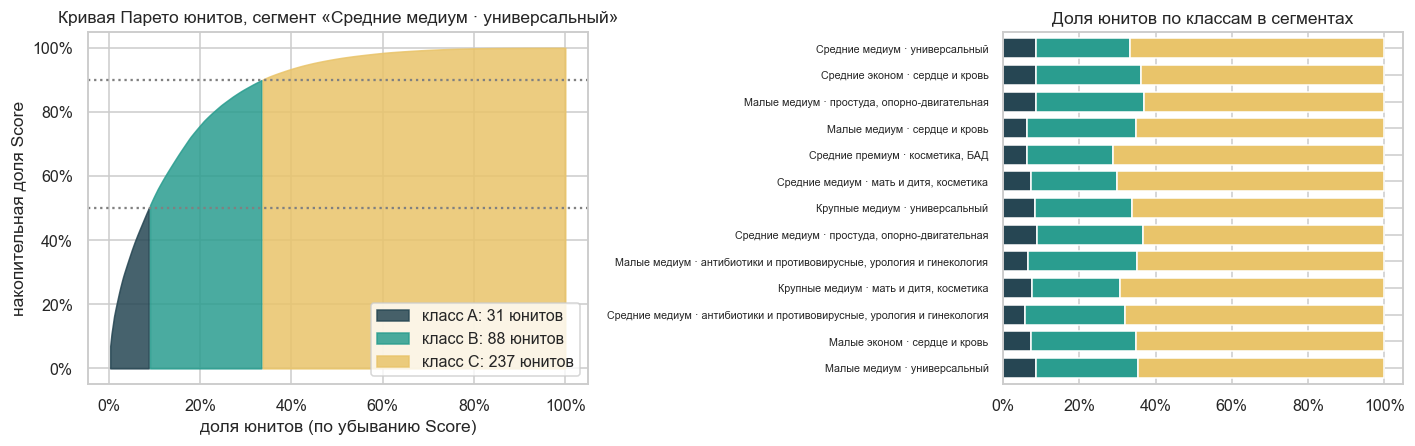

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={'width_ratios': [1.25, 1]})
biggest = n_stores.idxmax()
u = units[units.clst == biggest].reset_index(drop=True)
x = np.arange(1, len(u) + 1) / len(u)
colors = {'A': '#264653', 'B': '#2a9d8f', 'C': '#e9c46a'}
for status, part in u.groupby('Status'):
    axes[0].fill_between(x[part.index], 0, part.cum_share, color=colors[status], alpha=.85, label=f'класс {status}: {len(part)} юнитов')
axes[0].axhline(ABC_LOWER_BOUND, color='grey', ls=':'); axes[0].axhline(ABC_UPPER_BOUND, color='grey', ls=':')
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(1)); axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1))
axes[0].set(title=f'Кривая Парето юнитов, сегмент «{biggest}»', xlabel='доля юнитов (по убыванию Score)',
            ylabel='накопительная доля Score'); axes[0].legend(loc='lower right')

share = units.groupby('clst').Status.value_counts(normalize=True).unstack()[['A', 'B', 'C']]
share = share.loc[n_stores.sort_values().index]
share.plot.barh(stacked=True, color=[colors[s] for s in 'ABC'], ax=axes[1], width=.75, legend=False)
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(1))
axes[1].set(title='Доля юнитов по классам в сегментах', xlabel='', ylabel='')
axes[1].tick_params(axis='y', labelsize=7)
plt.tight_layout(); plt.show()

In [12]:
# нормированный скор товара внутри своего юнита (доля товара в скоре юнита) - используется порогами матрицы
df = df.merge(units[["clst", "Unit", "score_unit", "share_by_cluster", "Status"]], on=["clst", "Unit"])
df["score_norm_ap"] = (df["score"] / df["score_unit"]).fillna(0)
# вес юнита относительно крупнейшего юнита сегмента - вход экспоненциального порога
df["share_rel"] = df["share_by_cluster"] / df.groupby("clst")["share_by_cluster"].transform("max")

### Кандидаты на матрицу: ABC-пороги

In [13]:
results = []
for _, row in ABC_THRESHOLD_CANDIDATES.iterrows():
    col = f"in_matrix_{row['method']}"
    df[col] = df.apply(lambda r: matrix_sign_by_abc_threshold(r, row["a"], row["b"], row["c"], row["s_u"]), axis=1)
    apply_protection(df, col)
    results.append(evaluate_matrix_variant(df, col, row["method"]))

abc_variants = pd.concat(results, ignore_index=True)
abc_variants

,вариант,stock_rub,revenue,profit,позиций
0,мягкий,"692,828,311.03","527,866,495.07","134,224,749.31",18575
1,средний,"630,179,034.69","504,302,407.69","128,446,816.02",16792
2,строгий,"569,153,912.44","473,913,489.07","120,847,125.04",14986


### Кандидаты на матрицу: экспоненциальный порог

Порог для товара зависит от веса его юнита в сегменте: у весомых юнитов порог низкий (в матрицу проходит
больше товаров - покупателю нужен выбор), у мелких - высокий (достаточно одного-двух лидеров).

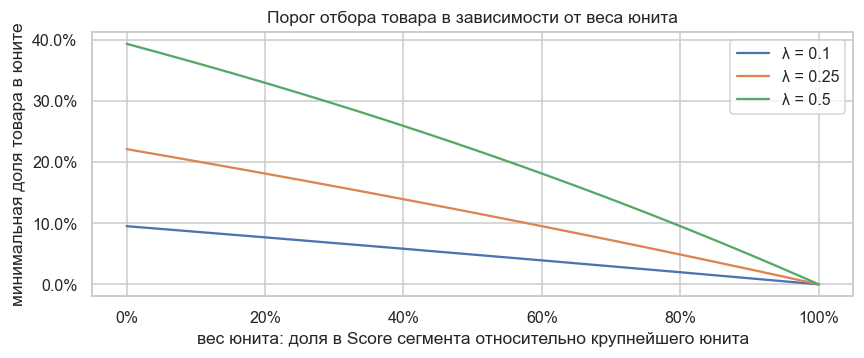

In [14]:
share_grid = np.linspace(0, 1, 200)
plt.figure(figsize=(8, 3.4))
for lam in LAMBDAS:
    plt.plot(share_grid, expon.cdf(1 - share_grid, scale=1 / lam), label=f'λ = {lam}')
plt.gca().xaxis.set_major_formatter(mticker.PercentFormatter(1, decimals=0))
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(1))
plt.xlabel('вес юнита: доля в Score сегмента относительно крупнейшего юнита'); plt.ylabel('минимальная доля товара в юните')
plt.title('Порог отбора товара в зависимости от веса юнита'); plt.legend(); plt.tight_layout(); plt.show()

In [15]:
results = []
for lam in LAMBDAS:
    col = f"in_matrix_exp_{lam}"
    df[col] = df.apply(lambda r: matrix_sign_by_exponential_bound(r, lam), axis=1)
    apply_protection(df, col)
    results.append(evaluate_matrix_variant(df, col, f"экспоненциальный (λ={lam})"))

exp_variants = pd.concat(results, ignore_index=True)
exp_variants

,вариант,stock_rub,revenue,profit,позиций
0,экспоненциальный (λ=0.1),"695,698,982.44","529,371,980.06","134,716,656.57",19993
1,экспоненциальный (λ=0.25),"588,580,588.68","484,621,740.65","123,740,305.71",16639
2,экспоненциальный (λ=0.5),"496,541,490.33","417,986,775.97","106,873,533.43",14883


### Сравнение всех кандидатов с действующей матрицей

In [16]:
fact_variant = evaluate_matrix_variant(df, "in_matrix_fact", "факт")
all_variants = pd.concat([fact_variant, abc_variants, exp_variants], ignore_index=True)

fact_row = all_variants[all_variants["вариант"] == "факт"].iloc[0]
for metric in ["stock_rub", "revenue", "profit", "позиций"]:
    all_variants[f"diff_{metric}"] = all_variants[metric] - fact_row[metric]

all_variants.style.format({c: '{:,.0f}' for c in all_variants.columns if c != 'вариант'})

,вариант,stock_rub,revenue,profit,позиций,diff_stock_rub,diff_revenue,diff_profit,diff_позиций
0,факт,"659,638,759","503,269,878","127,990,292","24,557",0,0,0,0
1,мягкий,"692,828,311","527,866,495","134,224,749","18,575","33,189,552","24,596,617","6,234,457","-5,982"
2,средний,"630,179,035","504,302,408","128,446,816","16,792","-29,459,725","1,032,530","456,524","-7,765"
3,строгий,"569,153,912","473,913,489","120,847,125","14,986","-90,484,847","-29,356,389","-7,143,167","-9,571"
4,экспоненциальный (λ=0.1),"695,698,982","529,371,980","134,716,657","19,993","36,060,223","26,102,102","6,726,365","-4,564"
5,экспоненциальный (λ=0.25),"588,580,589","484,621,741","123,740,306","16,639","-71,058,171","-18,648,137","-4,249,986","-7,918"
6,экспоненциальный (λ=0.5),"496,541,490","417,986,776","106,873,533","14,883","-163,097,269","-85,283,102","-21,116,759","-9,674"


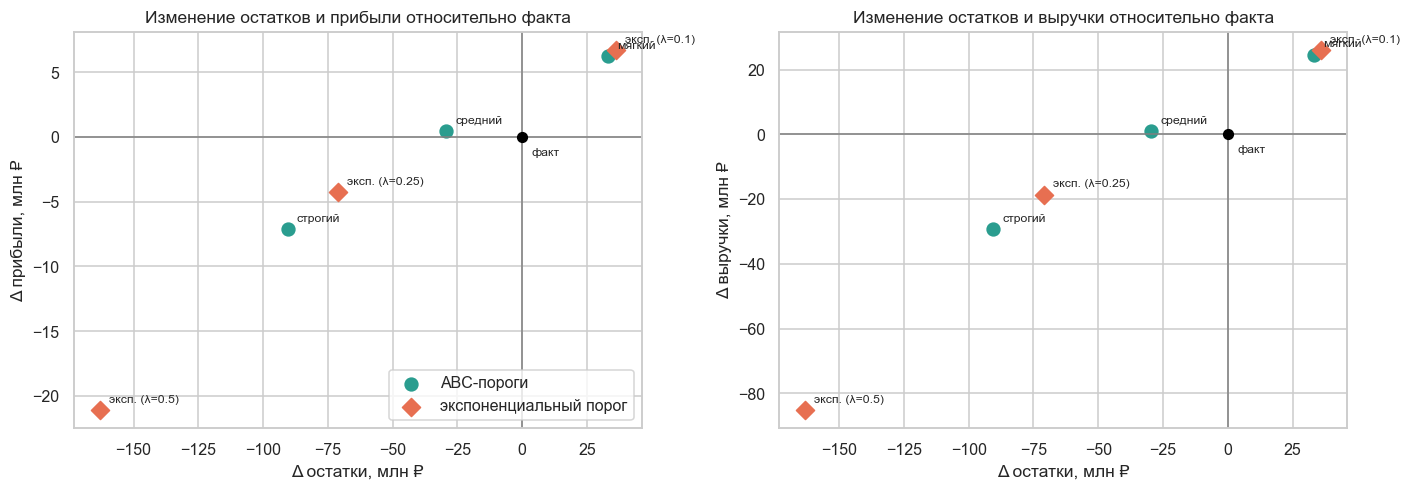

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
cand = all_variants[all_variants['вариант'] != 'факт']
for ax, metric, title in [(axes[0], 'diff_profit', 'прибыли'), (axes[1], 'diff_revenue', 'выручки')]:
    is_exp = cand['вариант'].str.startswith('эксп')
    ax.scatter(cand.diff_stock_rub[~is_exp] / 1e6, cand[metric][~is_exp] / 1e6, s=70, color='#2a9d8f', label='ABC-пороги')
    ax.scatter(cand.diff_stock_rub[is_exp] / 1e6, cand[metric][is_exp] / 1e6, s=70, color='#e76f51', marker='D',
               label='экспоненциальный порог')
    for _, r in cand.iterrows():
        ax.annotate(r['вариант'].replace('экспоненциальный ', 'эксп. '), (r.diff_stock_rub / 1e6, r[metric] / 1e6),
                    textcoords='offset points', xytext=(6, 5), fontsize=8)
    ax.axhline(0, color='grey', lw=1); ax.axvline(0, color='grey', lw=1)
    ax.scatter([0], [0], color='black', s=40, zorder=3); ax.annotate('факт', (0, 0), xytext=(6, -12), textcoords='offset points', fontsize=8)
    ax.set(title=f'Изменение остатков и {title} относительно факта', xlabel='Δ остатки, млн ₽', ylabel=f'Δ {title}, млн ₽')
axes[0].legend(loc='lower right')
plt.tight_layout(); plt.show()

В оригинальном расчёте вариант выбирали вручную по этой таблице и scatter-графику: интересны варианты, где
прибыль растёт или почти не падает, а капитал в остатках сокращается. Здесь то же правило формализовано:
**из вариантов, которые не увеличивают остатки, выбирается вариант с максимальной прибылью**.

In [18]:
not_more_stock = cand[cand.diff_stock_rub <= 0]
best = (not_more_stock if len(not_more_stock) else cand).sort_values('profit', ascending=False).iloc[0]
best_col = {r['method']: f"in_matrix_{r['method']}" for _, r in ABC_THRESHOLD_CANDIDATES.iterrows()}
best_col.update({f"экспоненциальный (λ={lam})": f"in_matrix_exp_{lam}" for lam in LAMBDAS})
selected = best_col[best['вариант']]
print(f"Выбран вариант: {best['вариант']}")
print(f"  остатки {best.diff_stock_rub / 1e6:+.1f} млн ₽ ({best.diff_stock_rub / fact_row.stock_rub:+.0%}), "
      f"выручка {best.diff_revenue / 1e6:+.1f} млн ₽ ({best.diff_revenue / fact_row.revenue:+.1%}), "
      f"прибыль {best.diff_profit / 1e6:+.1f} млн ₽ ({best.diff_profit / fact_row.profit:+.1%}), "
      f"позиций {int(best['diff_позиций']):+,}")

Выбран вариант: средний
  остатки -29.5 млн ₽ (-4%), выручка +1.0 млн ₽ (+0.2%), прибыль +0.5 млн ₽ (+0.4%), позиций -7,765


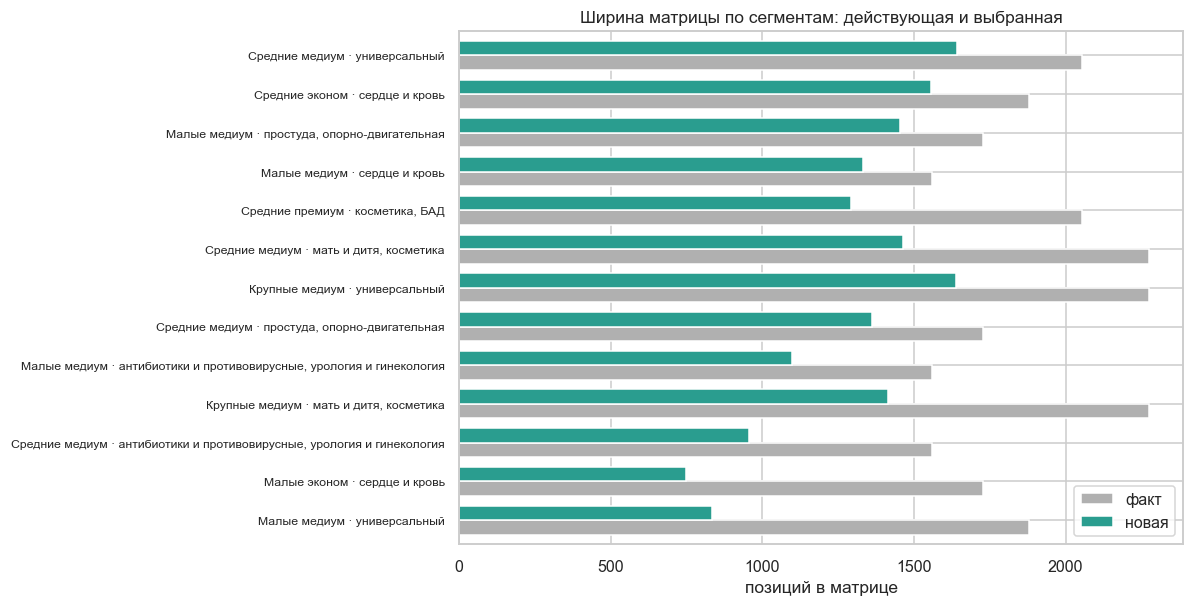

In [19]:
width = df.groupby('clst').agg(факт=('in_matrix_fact', 'sum'), новая=(selected, 'sum'))
width = width.loc[n_stores.sort_values().index]
ax = width.plot.barh(figsize=(11, 0.32 * len(width) + 1.5), color=['#b0b0b0', '#2a9d8f'], width=.75)
ax.set(title='Ширина матрицы по сегментам: действующая и выбранная', xlabel='позиций в матрице', ylabel='')
ax.tick_params(axis='y', labelsize=8); plt.tight_layout(); plt.show()

### Итоговая матрица

In [20]:
final_matrix = df[df[selected] == 1][['clst', 'apCode', 'name', 'Unit', 'Status', 'score', 'score_norm_ap',
                                      'is_min_assortment', 'is_own_brand', 'in_matrix_fact']]
changes = pd.crosstab(df.clst, [df.in_matrix_fact.map({1: 'был', 0: 'не был'}), df[selected].map({1: 'в новой', 0: 'вне новой'})])
print(f'{len(final_matrix):,} позиций в {final_matrix.clst.nunique()} сегментах')
changes.head(8)

16,792 позиций в 13 сегментах


in_matrix_fact                                         был            не был  \
in_matrix_средний                                  в новой вне новой в новой   
clst                                                                           
Крупные медиум · мать и дитя, косметика               1258      1017     155   
Крупные медиум · универсальный                        1462       813     177   
Малые медиум · антибиотики и противовирусные, у...     806       755     293   
Малые медиум · простуда, опорно-двигательная          1169       560     285   
Малые медиум · сердце и кровь                         1038       523     293   
Малые медиум · универсальный                           658      1220     175   
Малые эконом · сердце и кровь                          574      1155     174   
Средние медиум · антибиотики и противовирусные,...     687       874     269   

in_matrix_fact                                                
in_matrix_средний                                  вне новой  
clst                                                          
Крупные медиум · мать и дитя, косметика                  561  
Крупные медиум · универсальный                           704  
Малые медиум · антибиотики и противовирусные, у...       659  
Малые медиум · простуда, опорно-двигательная             969  
Малые медиум · сердце и кровь                            945  
Малые медиум · универсальный                             306  
Малые эконом · сердце и кровь                            215  
Средние медиум · антибиотики и противовирусные,...       491

In [21]:
def save(frame: pd.DataFrame, table: str):
    con.execute('CREATE SCHEMA IF NOT EXISTS results')
    con.register('tmp_df', frame)
    con.execute(f'CREATE OR REPLACE TABLE results.{table} AS SELECT * FROM tmp_df')
    con.unregister('tmp_df')


save(final_matrix.rename(columns={'clst': 'segment'}), 'assortment_matrix')

# агрегаты для графиков на сайте
save(units[['clst', 'Unit', 'score_unit', 'share_by_cluster', 'cum_share', 'Status']].rename(columns={'clst': 'segment'}),
     'scoring_units')
variants = all_variants.rename(columns={'вариант': 'variant', 'позиций': 'positions', 'diff_позиций': 'diff_positions'})
variants['selected'] = variants.variant == best['вариант']
save(variants, 'scoring_variants')
save(width.reset_index().rename(columns={'clst': 'segment', 'факт': 'fact', 'новая': 'new'})
     .merge(n_stores.rename('n_stores'), left_on='segment', right_index=True), 'scoring_width')
con.close()
print(f'results.assortment_matrix: {len(final_matrix):,} строк')

results.assortment_matrix: 16,792 строк

## Отличия от оригинального расчёта

- **Score считается по продажам** сегмента (выручка на точку с поправкой на ценовой уровень), а не задан
  случайно, как в прежней портфолио-версии; в оригинале Score брался из отдельного расчёта.
- **Юниты** построены из справочника: МНН + лекарственная форма; в оригинале - готовый справочник юнитов.
- **Защищённые позиции** (минимальный ассортимент, СТМ) включены как переключаемая опция.
- **Переключение спроса**: при исключении товара половина его выручки переходит на аналоги из того же юнита -
  иначе любое сокращение матрицы выглядело бы как прямая потеря продаж.
- **Выбор варианта формализован** (максимум прибыли без роста остатков) вместо ручного выбора по графику.
- В экспоненциальный порог подаётся доля юнита **относительно крупнейшего юнита сегмента**: при сотнях юнитов
  доля каждого - доли процента, и исходная формула от абсолютной доли отсекала бы почти весь ассортимент.